In [ ]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [ ]:
BASE_DIR = Path("/home/nathan/Documents/Projects/IA/Projeto_IA_Tumor")

DATASET_DIR = BASE_DIR / "data/dataset"

OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
CONFUSION_DIR = OUTPUT_DIR / "confusion_matrix"

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0001

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

RANDOM_SEED = 42

DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

In [ ]:
class TumorDataset(Dataset):
    def __init__(self, samples, class_to_idx):
        self.samples = samples
        self.class_to_idx = class_to_idx

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        relative_path = str(image_path).split("dataset/")[-1]
        relative_path = relative_path.replace("/", "\\")

        image = Image.fromarray(image)
        image = self.transform(image)

        label = self.class_to_idx[class_name]

        return image, label

In [ ]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)

print(f"Usando dispositivo: {DEVICE}")

all_samples = []
classes = []

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        class_name = class_dir.name
        classes.append(class_name)

        for image_path in class_dir.glob("*.jpg"):
            all_samples.append((image_path, class_name))

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

train_samples, temp_samples = train_test_split(
    all_samples,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=[x[1] for x in all_samples]
)

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=[x[1] for x in temp_samples]
)

train_dataset = TumorDataset(train_samples, class_to_idx)
val_dataset = TumorDataset(val_samples, class_to_idx)
test_dataset = TumorDataset(test_samples, class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Classes:", classes)
print("Total de imagens:", len(all_samples))
print("Imagens de treinamento:", len(all_samples))
print("Imagens de validacao:", len(val_samples))
print("Imagens de teste:", len(test_samples))

In [6]:
model = BrainTumorCNN(num_classes=len(classes)).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
val_accuracies = []

best_accuracy = 0

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    accuracy = accuracy_score(all_labels, all_preds)
    val_accuracies.append(accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Accuracy={accuracy:.4f}"
    )

    if accuracy > best_accuracy:
        best_accuracy = accuracy

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": class_to_idx,
            "accuracy": accuracy,
        }, MODEL_DIR / "best_model.pth")

print("Treinamento concluído")

Epoch 1/50 - Loss: 3.1972: 100%|██████████| 495/495 [00:36<00:00, 13.57it/s]


Epoch 1: Train Loss=3.0488 | Val Loss=2.3375 | Accuracy=0.3327


Epoch 2/50 - Loss: 1.1039: 100%|██████████| 495/495 [00:30<00:00, 16.26it/s]


Epoch 2: Train Loss=2.1852 | Val Loss=1.5553 | Accuracy=0.5440


Epoch 3/50 - Loss: 1.8135: 100%|██████████| 495/495 [00:30<00:00, 16.27it/s]


...

Epoch 48: Train Loss=0.1121 | Val Loss=0.2326 | Accuracy=0.9398


Epoch 49/50 - Loss: 0.1799: 100%|██████████| 495/495 [00:30<00:00, 16.15it/s]


Epoch 49: Train Loss=0.1067 | Val Loss=0.2050 | Accuracy=0.9587


Epoch 50/50 - Loss: 0.0006: 100%|██████████| 495/495 [00:30<00:00, 16.16it/s]


Epoch 50: Train Loss=0.0904 | Val Loss=0.2373 | Accuracy=0.9487
Treinamento concluído


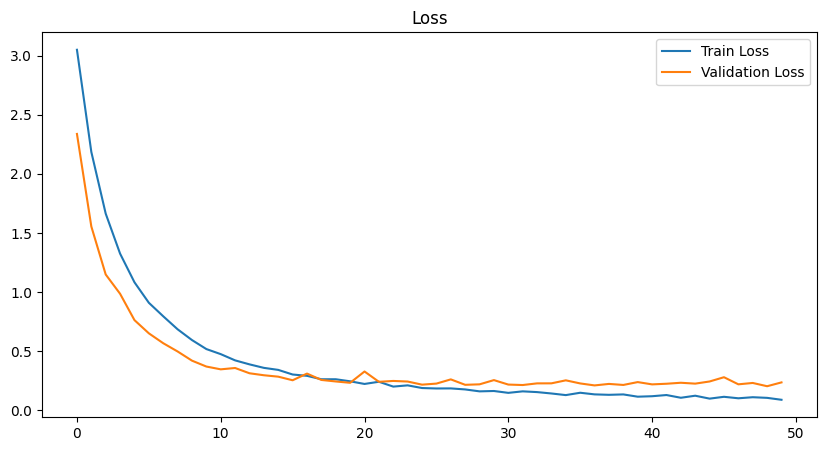

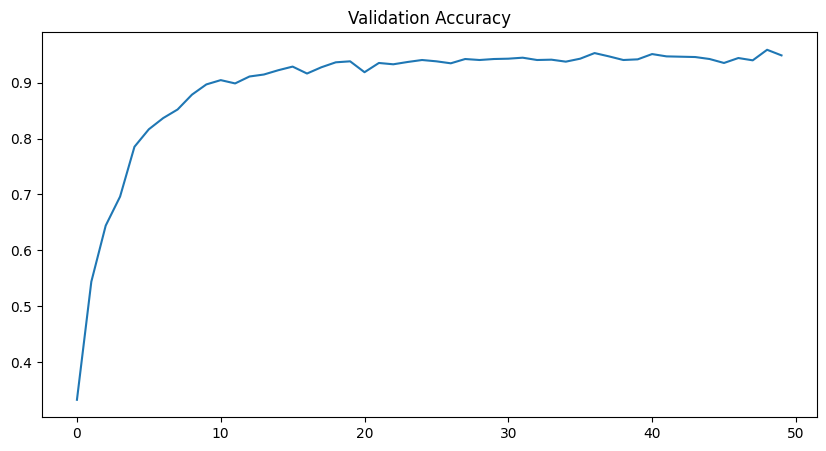

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.savefig(PLOT_DIR / "loss_curve.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.savefig(PLOT_DIR / "accuracy_curve.png")
plt.show()

In [8]:
checkpoint = torch.load(MODEL_DIR / "best_model.pth")

model = BrainTumorCNN(num_classes=len(class_to_idx))
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)

model.eval()

test_dataset = TumorDataset(test_samples, class_to_idx)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_to_idx.keys()
))

Accuracy: 0.9540
                         precision    recall  f1-score   support

         Astrocytoma T1       0.93      0.95      0.94        59
       Astrocytoma T1C+       0.94      0.94      0.94        66
         Astrocytoma T2       0.86      0.86      0.86        42
          Ependymoma T1       0.94      1.00      0.97        47
        Ependymoma T1C+       0.98      0.98      0.98        56
          Ependymoma T2       0.88      0.94      0.91        52
              Glioma T1       0.95      0.99      0.97        79
            Glioma T1C+       1.00      1.00      1.00        83
              Glioma T2       0.85      0.95      0.90        61
  Hemangiopericytoma T1       0.96      1.00      0.98        27
Hemangiopericytoma T1C+       0.98      1.00      0.99        46
  Hemangiopericytoma T2       1.00      0.59      0.74        17
          Meningioma T1       0.99      0.95      0.97        96
        Meningioma T1C+       0.97      0.97      0.97       147
       

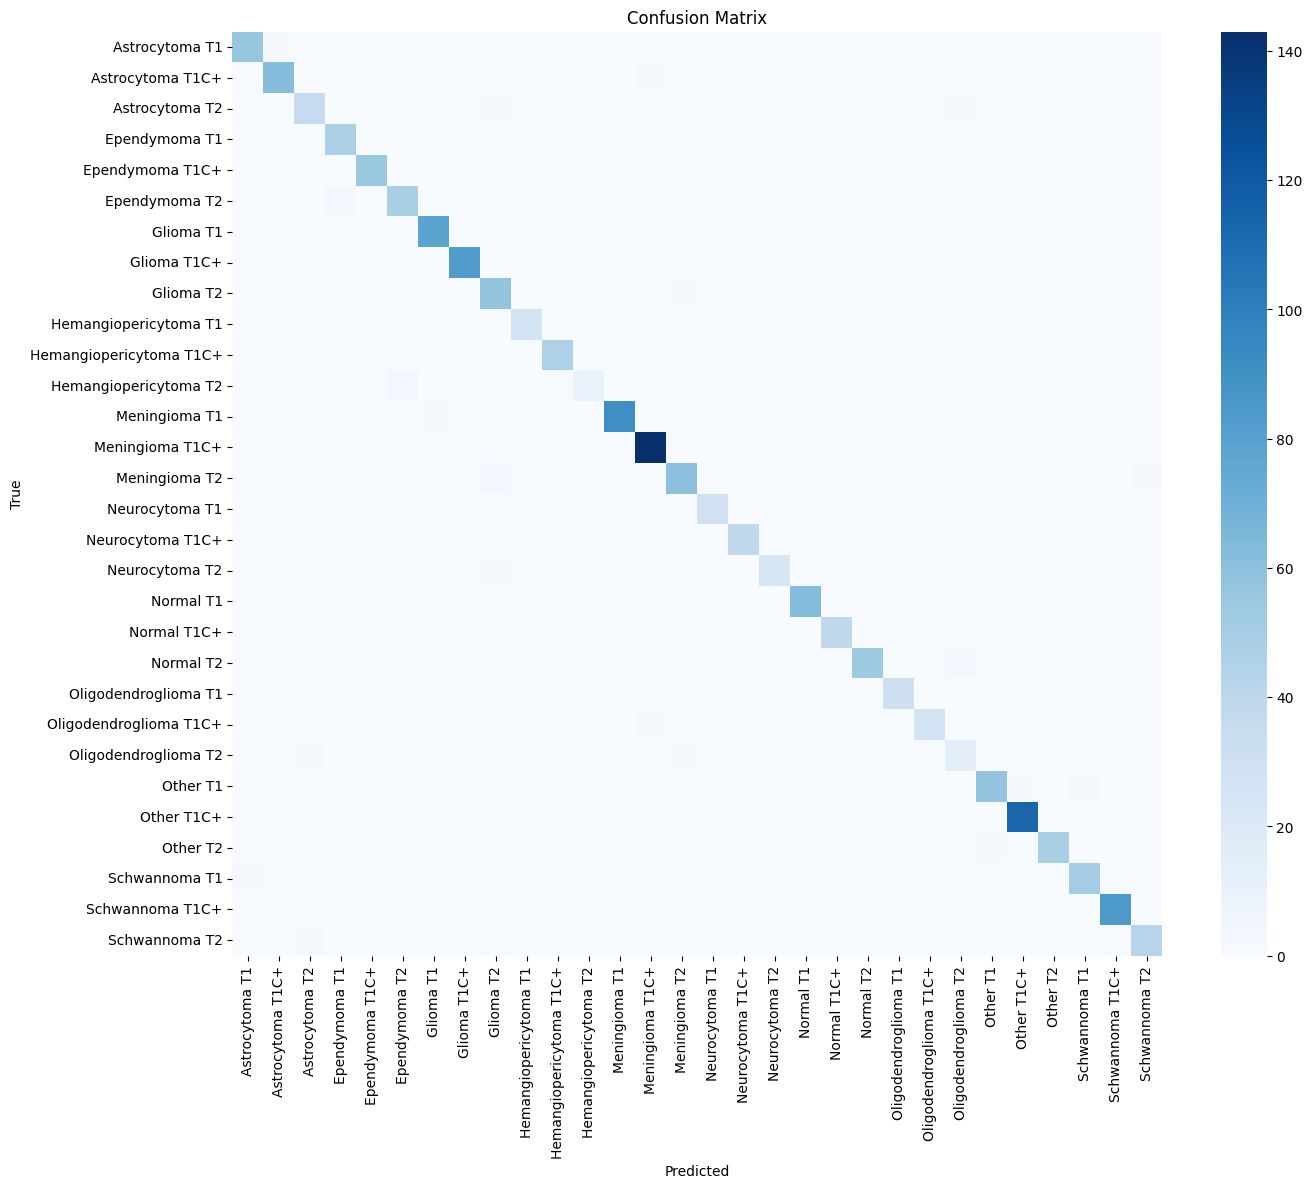

In [9]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_to_idx.keys(),
    yticklabels=class_to_idx.keys()
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(CONFUSION_DIR / "confusion_matrix.png")

plt.show()

Classe prevista: Astrocytoma T2
Confiança: 98.98%


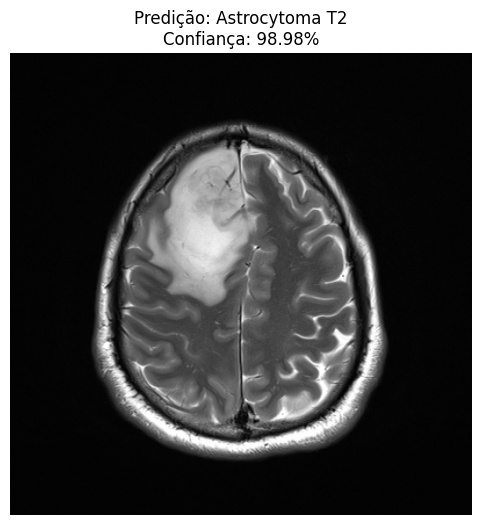

In [10]:
image_path = "/home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/data/dataset/Astrocytoma T2/T2 - Astrocytoma frontal , falx 009.jpg"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Imagem não encontrada: {image_path}")

# Transformações
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# Carrega imagem
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Erro ao carregar imagem")

# Mantém original para visualização
original_image = image.copy()

# PIL
image_pil = Image.fromarray(image)

# Tensor
image_tensor = transform(image_pil).unsqueeze(0).to(DEVICE)

# Inferência
model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = torch.softmax(output, dim=1)

    predicted_class = torch.argmax(probabilities, dim=1).item()

    confidence = probabilities[0][predicted_class].item()

predicted_label = idx_to_class[predicted_class]

print(f"Classe prevista: {predicted_label}")
print(f"Confiança: {confidence * 100:.2f}%")

# Exibe imagem
plt.figure(figsize=(6, 6))

plt.imshow(original_image, cmap="gray")

plt.title(
    f"Predição: {predicted_label}\n"
    f"Confiança: {confidence*100:.2f}%"
)

plt.axis("off")

plt.show()

In [11]:
# Caminhos
final_model_path = MODEL_DIR / "final_model_weights.pth"

checkpoint_path = MODEL_DIR / "complete_checkpoint.pth"

# Salva pesos
torch.save(
    model.state_dict(),
    final_model_path
)

# Salva checkpoint completo
checkpoint = {

    "model_state_dict": model.state_dict(),

    "optimizer_state_dict": optimizer.state_dict(),

    "class_to_idx": class_to_idx,

    "idx_to_class": idx_to_class,

    "best_accuracy": best_accuracy,

    "epochs": EPOCHS,

    "learning_rate": LEARNING_RATE
}

torch.save(
    checkpoint,
    checkpoint_path
)

print("Modelo salvo com sucesso")

print(f"Pesos: {final_model_path}")

print(f"Checkpoint: {checkpoint_path}")

Modelo salvo com sucesso
Pesos: /home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/outputs/models/final_model_weights.pth
Checkpoint: /home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/outputs/models/complete_checkpoint.pth


In [12]:
# Recria arquitetura
loaded_model = BrainTumorCNN(
    num_classes=len(class_to_idx)
)

# Carrega checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

# Carrega pesos
loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Move para dispositivo
loaded_model.to(DEVICE)

loaded_model.eval()

print("Modelo carregado com sucesso")

print(
    "Melhor accuracy:",
    checkpoint["best_accuracy"]
)

Modelo carregado com sucesso
Melhor accuracy: 0.9587020648967551


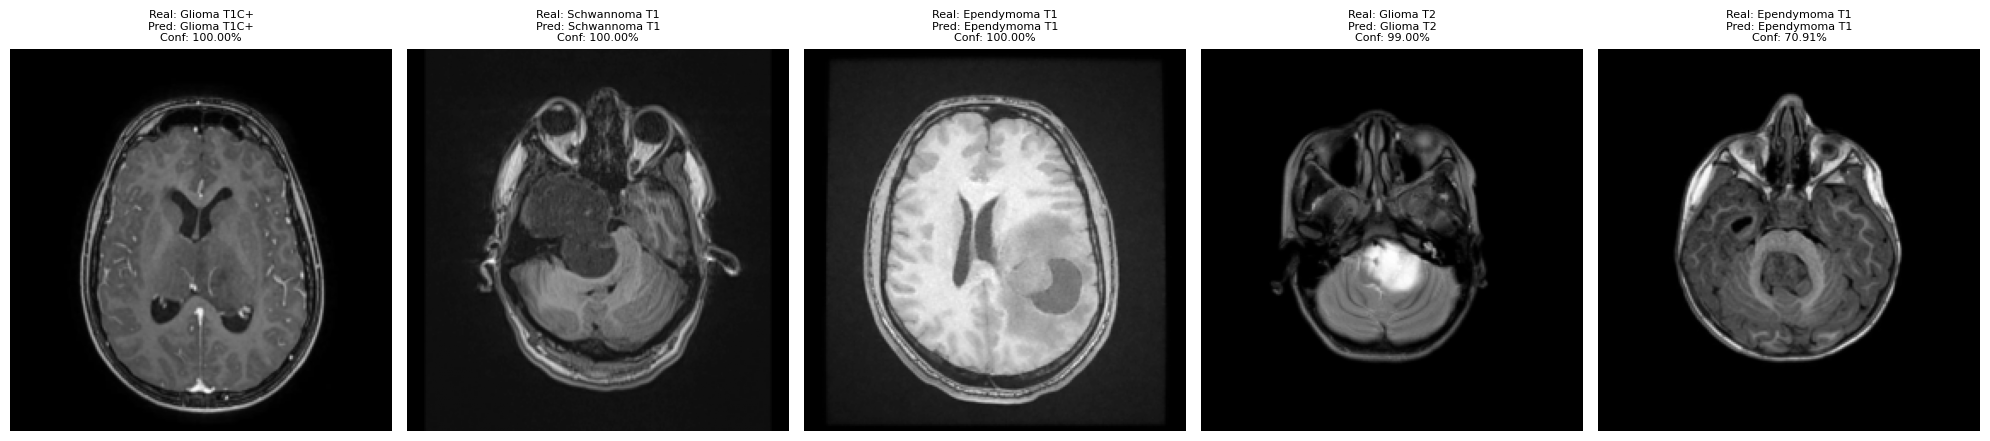

In [13]:
num_images = 5

model.eval()

fig, axes = plt.subplots(
    1,
    num_images,
    figsize=(20, 5)
)

with torch.no_grad():

    for i in range(num_images):

        image, label = test_dataset[i]

        input_tensor = image.unsqueeze(0).to(DEVICE)

        # Forward
        output = model(input_tensor)

        # Probabilidades
        probabilities = torch.softmax(output, dim=1)

        # Classe prevista
        pred = torch.argmax(
            probabilities,
            dim=1
        ).item()

        # Confiança
        confidence = probabilities[0][pred].item()

        image_np = image.squeeze().cpu().numpy()

        axes[i].imshow(
            image_np,
            cmap="gray"
        )

        axes[i].set_title(
            f"Real: {idx_to_class[label]}\n"
            f"Pred: {idx_to_class[pred]}\n"
            f"Conf: {confidence*100:.2f}%",
            fontsize=8
        )

        axes[i].axis("off")

plt.tight_layout()

plt.show()

In [14]:
print("=" * 50)
print("RESUMO FINAL DO TREINAMENTO")
print("=" * 50)

print(f"Número de classes: {len(classes)}")

print(f"Total de imagens: {len(all_samples)}")

print(f"Imagens treino: {len(train_samples)}")

print(f"Imagens validação: {len(val_samples)}")

print(f"Imagens teste: {len(test_samples)}")

print(
    f"\nMelhor accuracy: "
    f"{best_accuracy:.4f}"
)

print(
    f"Learning Rate: "
    f"{LEARNING_RATE}"
)

print(
    f"Batch Size: "
    f"{BATCH_SIZE}"
)

print(
    f"Épocas: "
    f"{EPOCHS}"
)

print(
    f"Dispositivo: "
    f"{DEVICE}"
)

print("=" * 50)

RESUMO FINAL DO TREINAMENTO
Número de classes: 30
Total de imagens: 11300
Imagens treino: 7910
Imagens validação: 1695
Imagens teste: 1695

Melhor accuracy: 0.9587
Learning Rate: 0.0001
Batch Size: 16
Épocas: 50
Dispositivo: cuda


In [15]:
test_folder = DATASET_DIR / list(class_to_idx.keys())[0]

model.eval()

results = []

with torch.no_grad():

    for image_path in test_folder.glob("*.jpg"):

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        image_pil = Image.fromarray(image)

        tensor = transform(image_pil)\
            .unsqueeze(0)\
            .to(DEVICE)

        output = model(tensor)

        probs = torch.softmax(output, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        confidence = probs[0][pred].item()

        results.append({
            "image": image_path.name,
            "prediction": idx_to_class[pred],
            "confidence": confidence
        })

df_results = pd.DataFrame(results)

print(df_results.head())

                                               image      prediction  \
0  T1 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T1   
1  T1 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T1   
2  T1 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T1   
3  T1 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T1   
4            T1 - Anaplastic astrocytoma NOS 004.jpg  Astrocytoma T1   

   confidence  
0    0.999298  
1    0.992983  
2    0.999175  
3    0.996036  
4    1.000000  
